
✅ RMSE (sqrt method): 476.02
✅ R²: 0.40


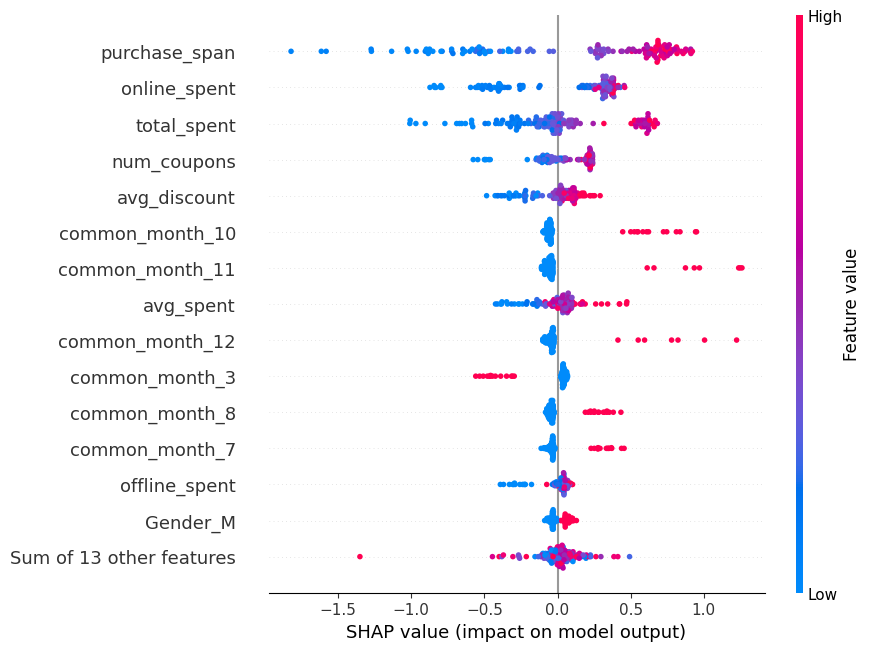

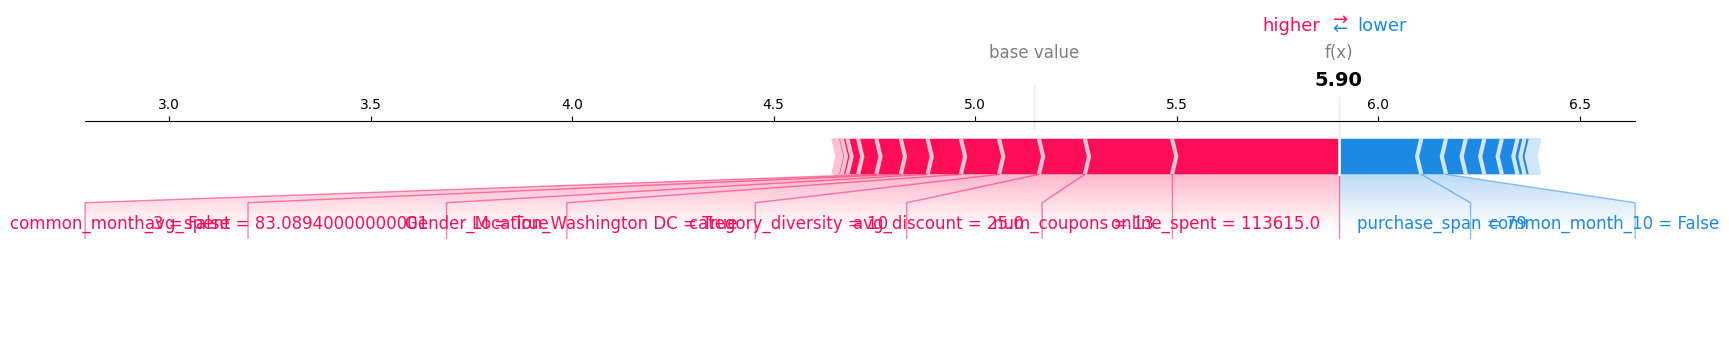


📁 Predictions exported to 'CLV_Predictions_With_Explanations.csv'


In [10]:
import pandas as pd
import numpy as np
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ---------- 1. Load and Clean Data ----------
df = pd.read_csv('file.csv')
df = df[df['CustomerID'].notnull()]
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], errors='coerce')
df.dropna(subset=['Transaction_Date'], inplace=True)
df['CustomerID'] = df['CustomerID'].astype(int)
df['TotalPrice'] = df['Quantity'] * df['Avg_Price']
df = df[df['TotalPrice'] > 0]

# ---------- 2. Create Snapshot Date ----------
snapshot_date = df['Transaction_Date'].max() + pd.Timedelta(days=1)

# ---------- 3. Compute CLV using BG/NBD & Gamma-Gamma ----------
summary = summary_data_from_transaction_data(
    df, 'CustomerID', 'Transaction_Date', 
    monetary_value_col='TotalPrice',
    observation_period_end=snapshot_date
)
summary = summary[summary['frequency'] > 0]

bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])
summary['pred_purchases'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    30 * 3, summary['frequency'], summary['recency'], summary['T'])

ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(summary['frequency'], summary['monetary_value'])
summary['exp_avg_value'] = ggf.conditional_expected_average_profit(
    summary['frequency'], summary['monetary_value'])

summary['base_clv'] = summary['pred_purchases'] * summary['exp_avg_value']
summary = summary.reset_index()

# ---------- 4. Merge base_clv back into the main dataframe ----------
df = df.merge(summary[['CustomerID', 'base_clv']], on='CustomerID', how='inner')

# ---------- 5. Aggregate Transaction Data to the Customer Level ----------
agg_features = df.groupby('CustomerID').agg({
    'Transaction_ID': 'nunique',
    'Transaction_Date': [lambda x: (x.max() - x.min()).days, 'count'],
    'TotalPrice': ['sum', 'mean'],
    'Online_Spend': 'sum',
    'Offline_Spend': 'sum',
    'Discount_pct': 'mean',
    'Coupon_Code': 'nunique',
    'Product_Category': 'nunique',
    'Month': lambda x: x.mode()[0] if not x.mode().empty else np.nan
}).reset_index()

agg_features.columns = ['CustomerID', 'num_txns', 'purchase_span', 'num_days',
                        'total_spent', 'avg_spent', 'online_spent', 'offline_spent',
                        'avg_discount', 'num_coupons', 'category_diversity', 'common_month']

# ---------- 6. Merge in Demographics ----------
demographics = df.groupby('CustomerID').agg({
    'Gender': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',
    'Location': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',
    'Tenure_Months': 'mean'
}).reset_index()

final_df = agg_features.merge(demographics, on='CustomerID', how='left')
final_df = final_df.merge(summary[['CustomerID', 'base_clv']], on='CustomerID', how='left')
final_df.dropna(inplace=True)

# ---------- 7. Outlier Removal ----------
Q1 = final_df['base_clv'].quantile(0.25)
Q3 = final_df['base_clv'].quantile(0.75)
IQR = Q3 - Q1
final_df = final_df[(final_df['base_clv'] >= Q1 - 1.5 * IQR) & (final_df['base_clv'] <= Q3 + 1.5 * IQR)]

# ---------- 8. Log Transform Target ----------
final_df['log_clv'] = np.log1p(final_df['base_clv'])

# ---------- 9. Feature Preparation ----------
X = final_df.drop(columns=['CustomerID', 'base_clv', 'log_clv'])
X['common_month'] = X['common_month'].astype(str)
categorical_cols = ['Gender', 'Location', 'common_month']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

y = final_df['log_clv']

# ---------- 10. Train/Test Split ----------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------- 11. XGBoost + GridSearchCV ----------
params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}
xgb = XGBRegressor(random_state=42)
grid = GridSearchCV(xgb, param_grid=params, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_

# ---------- 12. Evaluate ----------
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
print(f"\n✅ RMSE (sqrt method): {rmse:.2f}")
print(f"✅ R²: {r2:.2f}")

# ---------- 13. SHAP Explainability ----------
# explainer = shap.Explainer(best_model, X_train)
# shap_values = explainer(X_test)

# Beeswarm plot
shap.plots.beeswarm(shap_values, max_display=15)

# Force plot for 1st customer (optional)
shap.plots.force(shap_values[0], matplotlib=True)

# ---------- 14. Export Results ----------
results = X_test.copy()
results['Actual_CLV'] = y_true
results['Predicted_CLV'] = y_pred
results['CLV_Error'] = results['Actual_CLV'] - results['Predicted_CLV']
results.to_csv("CLV_Predictions_With_Explanations.csv", index=False)
print("\n📁 Predictions exported to 'CLV_Predictions_With_Explanations.csv'")
